# 🏠 House Price Prediction
## Week 9: Introduction to Machine Learning Concepts

This notebook demonstrates an end-to-end Machine Learning workflow to predict house prices based on various features such as area, bedrooms, age, and location. We will use `scikit-learn` to build, train, and evaluate our models.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("D:\Week9_Project\data\house_prices.csv")
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (300, 8)


,Property_ID,Area,Bedrooms,Bathrooms,Age,Location,Property_Type,Price
0,PROP0001,3712,4,3,36,Rural,House,22260000
1,PROP0002,1591,4,1,35,Suburb,House,16057500
2,PROP0003,1646,4,3,20,Rural,Villa,12730000
3,PROP0004,4814,1,2,13,City Center,Villa,50840000
4,PROP0005,800,4,2,38,Suburb,Apartment,10650000


### STEP2: Exploratory Data Analysis (EDA)

Missing Values:
 Property_ID      0
Area             0
Bedrooms         0
Bathrooms        0
Age              0
Location         0
Property_Type    0
Price            0
dtype: int64


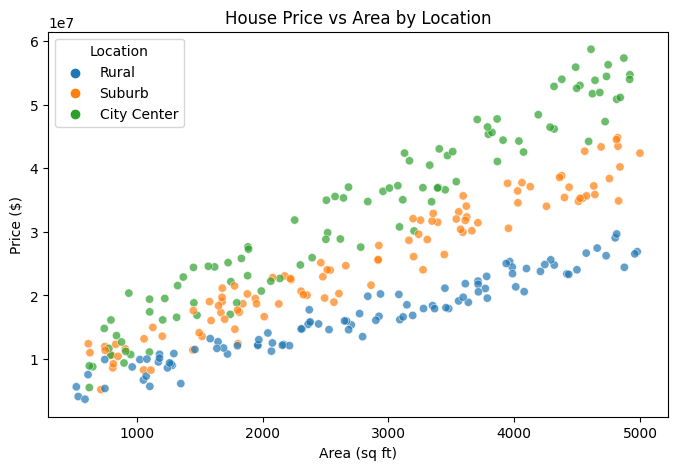

In [5]:
#Check for missing values
print("Missing Values:\n", df.isnull().sum())

#Visualize the relationship between Area and Price
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Area", y="Price", hue="Location", alpha=0.7)
plt.title("House Price vs Area by Location")
plt.xlabel("Area (sq ft)")
plt.ylabel("Price ($)")
plt.show()

### Step3: Data Preparation

In [6]:
#Dropping ID column as not useful for prediction
df_ml = df.drop('Property_ID', axis=1)

#Convert categorical vairables to dummy variables (One=Hot Encoding)
df_ml = pd.get_dummies(df_ml, columns=['Location', 'Property_Type'], drop_first=True)

#Define featuresw (X) and Target (Y)
X = df_ml.drop('Price', axis=1)
y = df_ml['Price']

#Train-test Split (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (240, 8)
Testing data shape: (60, 8)


### Step4: Build and Train Models

In [8]:
#1. Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

#2. Random forest Regressor(More advanced model)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

print("Models trained successfully!")

Models trained successfully!


### Step5: Evaluate Model Performance

In [18]:
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    print(f"--- {model_name} Performance ---")
    print(f"MAE:  ${mae:,.2f}")
    print(f"RMSE: ${rmse:,.2f}")
    print(f"R^2 Score: {r2:.4f}\n")

evaluate_model(y_test, lr_preds, "Linear Regression")
evaluate_model(y_test, rf_preds, "Random Forest Regressor")

--- Linear Regression Performance ---
MAE:  $2,188,736.34
RMSE: $2,907,633.21
R^2 Score: 0.9406

--- Random Forest Regressor Performance ---
MAE:  $1,493,949.17
RMSE: $2,029,855.84
R^2 Score: 0.9711



### Step6: Visualize Predictions vs Actual Results 

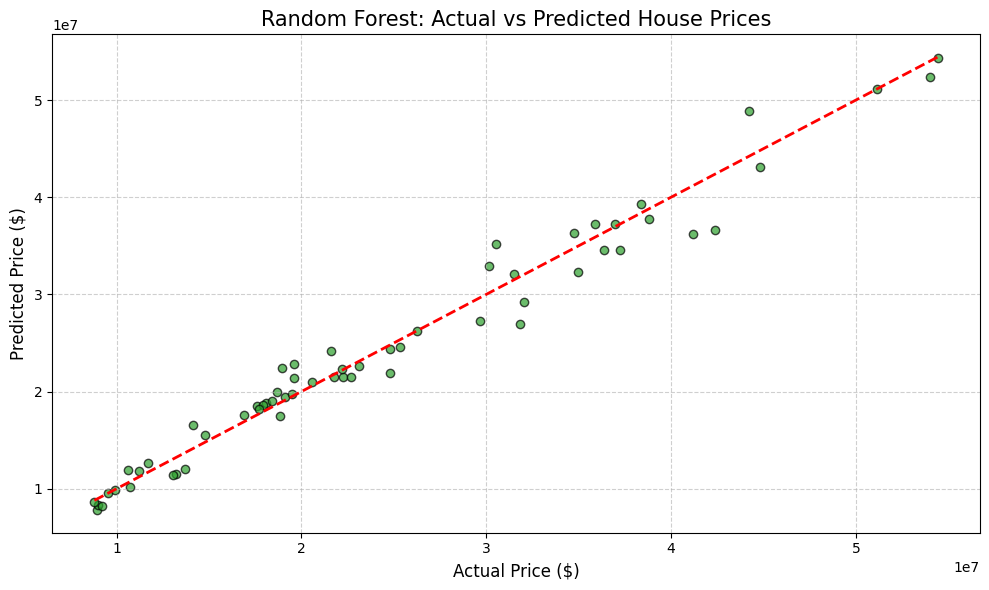

In [12]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, rf_preds, alpha=0.7, color='#2ca02c', edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price ($)', fontsize=12)
plt.ylabel('Predicted Price ($)', fontsize=12)
plt.title('Random Forest: Actual vs Predicted House Prices', fontsize=15)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('predictions_vs_actual.png', dpi=300)
plt.show()

### Step7: Interpret and Extract insights

Top Features Impacting House Prices:


,Feature,Importance
0,Area,0.693187
4,Location_Rural,0.201724
5,Location_Suburb,0.073616
1,Bedrooms,0.019140
3,Age,0.008199


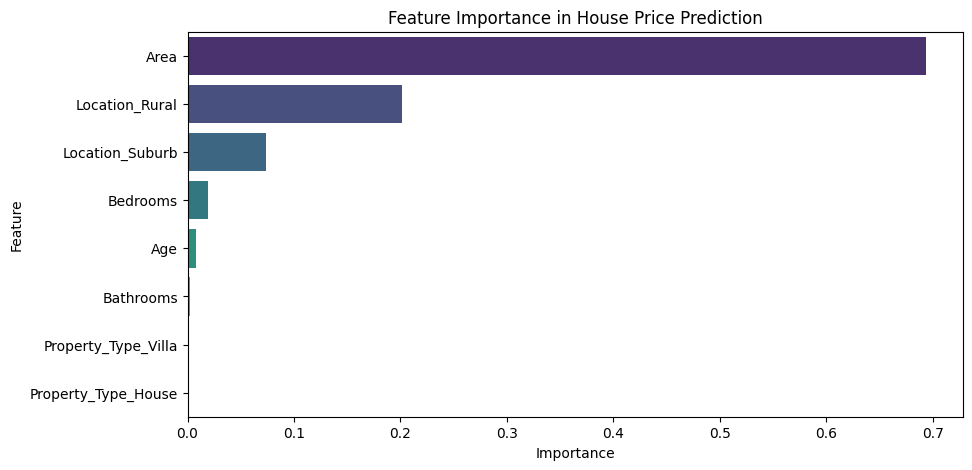

In [17]:
# Extract Feature Importances from Random Forest
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("Top Features Impacting House Prices:")
display(importances.head())

plt.figure(figsize=(10, 5))
sns.barplot(data=importances, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance in House Price Prediction')
plt.show()    